# 02. Benchmark: five models, one protocol

**Question.** Which family of models is cheapest under the Scania cost matrix, and is
the gap between the two best large enough to call a winner?

**Inputs.** `data/processed/X_fit.csv` and `y_fit.csv`, produced by
`scripts/build_dataset.py`.

**Outputs.** `reports/benchmark.csv`, figures 06 and 07.

**Protocol.** Frozen before any training, in `docs/evaluation_protocol.md`. Stratified
5-fold cross-validation, seed 42, class weighting at 50:1 from the cost matrix, and the
decision threshold measured inside each fold on out-of-sample probabilities. The
arbitration criterion is the total cost and nothing else. The arbitration margin is
2 000 units, and it was fixed before the first measurement.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR
from src.seeding import set_seed

set_seed()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 120)

2026-09-02 14:21:10.352634: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 14:21:10.395213: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from src.config import PROCESSED_DIR

X = pd.read_csv(PROCESSED_DIR / 'X_fit.csv', index_col=0)
y = pd.read_csv(PROCESSED_DIR / 'y_fit.csv', index_col=0).squeeze()
print(X.shape, int(y.sum()), 'failures', f'{y.mean():.4%}')

(48000, 180) 800 failures 1.6667%


## 1. Why the threshold cannot be tuned in sample

The first implementation tuned the decision threshold on the probabilities the model
predicted for the rows it had just been trained on. A random forest reproduces its own
training set almost perfectly, so the threshold found there was excellent in sample and
arbitrary outside it.

The two runs below are the same model under the same folds, differing only in where the
threshold comes from. This comparison is the reason the leaky path is still callable.

In [3]:
from src.evaluation import evaluate, report
from src.models import random_forest

leaky = evaluate(random_forest, X, y, name='random forest, in-sample threshold',
                 out_of_sample_threshold=False)
clean = evaluate(random_forest, X, y, name='random forest, out-of-sample threshold')

print('in-sample threshold     :', f"{leaky['cost'].mean():>10,.0f}")
print('out-of-sample threshold :', f"{clean['cost'].mean():>10,.0f}")
print('ratio                   :', f"{leaky['cost'].mean() / clean['cost'].mean():.1f}")

in-sample threshold     :     40,850
out-of-sample threshold :      6,926
ratio                   : 5.9


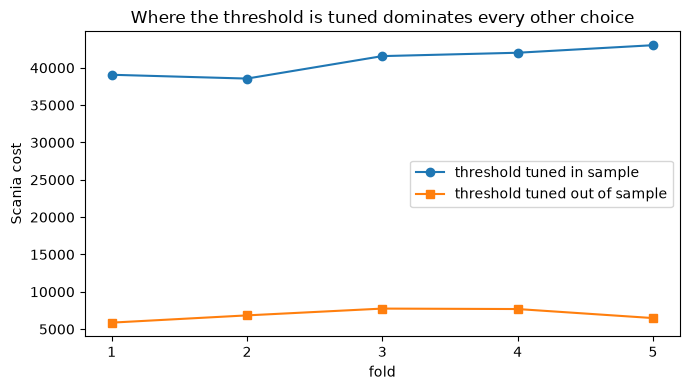

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(leaky['fold'], leaky['cost'], marker='o', label='threshold tuned in sample')
ax.plot(clean['fold'], clean['cost'], marker='s', label='threshold tuned out of sample')
ax.set_xticks(clean['fold'])
ax.set_xlabel('fold')
ax.set_ylabel('Scania cost')
ax.set_title('Where the threshold is tuned dominates every other choice')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_threshold_tuning.png', dpi=150)

## 2. The five models

Three ways of learning are represented, which is what makes the comparison say something
about families of methods rather than about five particular programs: linear models,
tree ensembles, and a neural network.

The configurations are those recorded in `docs/hyperparameter_grids.md`. The factory
defaults in `src/models.py` are deliberately neutral starting values and are not all the
same as the ones passed here.

The perceptron is slow and the linear SVM slower still, because of its internal Platt
calibration. Running this cell end to end takes a long time on a CPU.

In [5]:
from src.models import (KerasPerceptron, gradient_boosting, linear_svm,
                        logistic_regression, random_forest)

candidates = {
    'Gradient boosting 8/0.1': lambda: gradient_boosting(max_depth=8, learning_rate=0.1),
    'Random forest 300/None/1': lambda: random_forest(n_trees=300),
    'Perceptron (64, 32)': lambda: KerasPerceptron(units=(64, 32)),
    'Linear SVM C=0.001': lambda: linear_svm(C=0.001),
    'Logistic regression C=0.001': lambda: logistic_regression(C=0.001),
}

results = {}
for name, factory in candidates.items():
    results[name] = evaluate(factory, X, y, name=name)
    report(results[name])

  Gradient boosting 8/0.1
  MEAN COST :      6,554  +/-  827
  fold scale        : 9,600 rows, 160 failures
  never-flag rule   : 80,000
  mean unweighted threshold : 0.0000

                           mean       std
cost                  6554.0000  827.2122
recall                   0.9538    0.0163
precision                0.3527    0.0401
auc                      0.9886    0.0035
auc_pr                   0.8782    0.0162
TP                     152.6000    2.6077
FP                     285.4000   56.2388
FN                       7.4000    2.6077
threshold                0.0017    0.0007
unweighted_threshold     0.0000    0.0000
  Random forest 300/None/1
  MEAN COST :      6,926  +/-  804
  fold scale        : 9,600 rows, 160 failures
  never-flag rule   : 80,000
  mean unweighted threshold : 0.0006

                           mean       std
cost                  6926.0000  803.7599
recall                   0.9625    0.0117
precision                0.2822    0.0114
auc                

2026-09-02 14:29:53.490085: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different 2026-09-02 14:29:53.490085: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 14:29:53.529635: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-02 14:29:53.529777: I tensorflow/core/platform/cpu_feature_guard.cc:210] This Tenso

  Perceptron (64, 32)
  MEAN COST :      8,494  +/-  1,780
  fold scale        : 9,600 rows, 160 failures
  never-flag rule   : 80,000
  mean unweighted threshold : 0.0075

                           mean        std
cost                  8494.0000  1780.2472
recall                   0.9400     0.0228
precision                0.2944     0.0431
auc                      0.9846     0.0065
auc_pr                   0.7599     0.0262
TP                     150.4000     3.6469
FP                     369.4000    76.9597
FN                       9.6000     3.6469
threshold                0.2724     0.0241
unweighted_threshold     0.0075     0.0009
  Linear SVM C=0.001
  MEAN COST :      9,334  +/-  1,465
  fold scale        : 9,600 rows, 160 failures
  never-flag rule   : 80,000
  mean unweighted threshold : 0.0004

                           mean        std
cost                  9334.0000  1465.3259
recall                   0.9200     0.0218
precision                0.3393     0.0458
auc       

## 3. Constant control

A model that flags nothing is the cheaper of the two constant rules at fold scale. It is
carried in the table so that every cost is read against something.

In [6]:
from src.config import COST_FN
from sklearn.dummy import DummyClassifier

control = evaluate(lambda: DummyClassifier(strategy='constant', constant=0),
                   X, y, name='constant control')
results['constant control'] = control
print('never-flag cost at fold scale :',
      f"{COST_FN * (control['TP'] + control['FN']).mean():,.0f}")

never-flag cost at fold scale : 80,000


## 4. The comparison table

Mean and standard deviation over the five folds, as the protocol requires without
exception. The standard deviation is not decorative: it is what decides whether two
models can be told apart at all.

In [7]:
table = pd.DataFrame({
    name: {
        'cost': r['cost'].mean(),
        'dispersion': r['cost'].std(),
        'recall': r['recall'].mean(),
        'precision': r['precision'].mean(),
        'auc': r['auc'].mean(),
        'auc_pr': r['auc_pr'].mean(),
        'FN': r['FN'].mean(),
        'FP': r['FP'].mean(),
        'unweighted_threshold': r['unweighted_threshold'].mean(),
    }
    for name, r in results.items()
}).T.sort_values('cost')

table.to_csv(Path.cwd().parent / 'reports' / 'benchmark.csv')
table.round(4)

,cost,dispersion,recall,precision,auc,auc_pr,FN,FP,unweighted_threshold
Gradient boosting 8/0.1,6554.0,827.2122,0.9538,0.3527,0.9886,0.8782,7.4,285.4,0.0000
Random forest 300/None/1,6926.0,803.7599,0.9625,0.2822,0.9858,0.8303,6.0,392.6,0.0006
"Perceptron (64, 32)",8494.0,1780.2472,0.9400,0.2944,0.9846,0.7599,9.6,369.4,0.0075
Linear SVM C=0.001,9334.0,1465.3259,0.9200,0.3393,0.9809,0.7569,12.8,293.4,0.0004
Logistic regression C=0.001,9596.0,1221.7324,0.9275,0.2826,0.9773,0.7437,11.6,379.6,0.0145
constant control,80000.0,0.0000,0.0000,NaN,0.5000,0.0167,160.0,0.0,0.0000


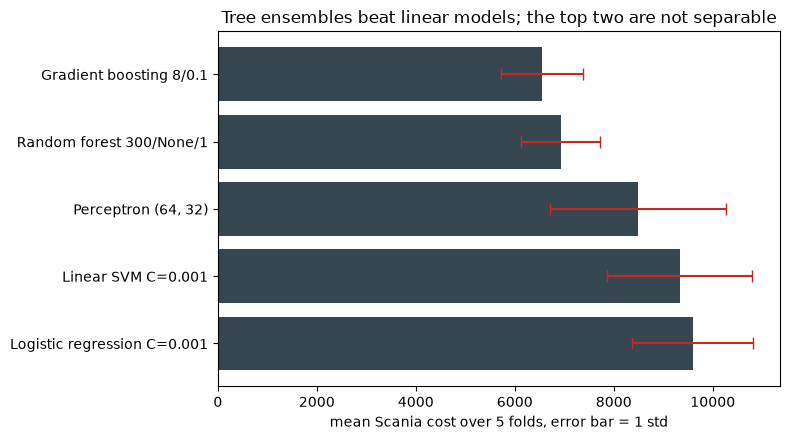

In [8]:
ranked = table.drop(index='constant control').sort_values('cost', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(ranked)), ranked['cost'], xerr=ranked['dispersion'],
        color='#37474f', ecolor='#c62828', capsize=4)
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(ranked.index)
ax.invert_yaxis()
ax.set_xlabel('mean Scania cost over 5 folds, error bar = 1 std')
ax.set_title('Tree ensembles beat linear models; the top two are not separable')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_model_ranking.png', dpi=150)

## What comes out of this notebook

**The tree family wins over the linear family**, by roughly 2 700 units, which clears
the 2 000 margin comfortably.

**No winner is declared between the top two.** Gradient boosting and the random forest
are 138 units apart for standard deviations of 1 030 and 530. Naming one of them the
best model would be reading noise.

**The measured thresholds sit far below 0.5 once unweighted**, in the region of the
1.96% analytical reference. That is a calibration diagnostic, not an operating point:
the threshold used is the measured one.

**The perceptron is the most dispersed model of the five**, which is what motivates
notebook 04: its objective is the only one that can be rewritten.